**Objective**


Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid.

Part A - Data preparation

In [2]:
!pip install pandas numpy matplotlib seaborn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
sentiment = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')


/tmp/ipython-input-1385013891.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv('historical_data.csv')


In [4]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)


Sentiment Shape: (2644, 4)
Trades Shape: (74503, 16)


In [5]:
sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
sentiment.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [8]:
trades.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74503 entries, 0 to 74502
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           74503 non-null  object 
 1   Coin              74503 non-null  object 
 2   Execution Price   74503 non-null  float64
 3   Size Tokens       74502 non-null  float64
 4   Size USD          74502 non-null  float64
 5   Side              74502 non-null  object 
 6   Timestamp IST     74502 non-null  object 
 7   Start Position    74502 non-null  float64
 8   Direction         74502 non-null  object 
 9   Closed PnL        74502 non-null  float64
 10  Transaction Hash  74502 non-null  object 
 11  Order ID          74502 non-null  float64
 12  Crossed           74502 non-null  object 
 13  Fee               74502 non-null  float64
 14  Trade ID          74502 non-null  float64
 15  Timestamp         74502 non-null  float64
dtypes: float64(9), object(7)
memory usage: 9

In [9]:
sentiment.isnull().sum()


,0
timestamp,0
value,0
classification,0
date,0


In [10]:
trades.isnull().sum()


,0
Account,0
Coin,0
Execution Price,0
Size Tokens,1
Size USD,1
Side,1
Timestamp IST,1
Start Position,1
Direction,1
Closed PnL,1


In [11]:
trades.duplicated().sum()


np.int64(0)

**Data Understanding**


**Sentiment Dataset**

Contains daily Bitcoin market sentiment using Fear & Greed Index

2644 records representing daily market psychology

Categories include Fear, Extreme Fear, Greed, Extreme Greed


**Trades Dataset**

Contains ~74K individual trades from Hyperliquid

Each row represents a single executed trade

Includes trader account, position size, direction, PnL, and timestamp


**Data Quality**

No duplicate rows found

Only 1 missing record in trading dataset (negligible → dropped)

Suitable for behavioral analysis


**Goal**

We will align each trade with the market sentiment of that day to analyze:

Whether trader performance changes with sentiment

Whether trader behavior changes with sentimen

In [12]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['Timestamp'].dt.date


In [13]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date


In [14]:
merged = pd.merge(trades, sentiment[['date','classification']], on='date', how='left')


In [15]:
merged.head()
merged['classification'].value_counts()


,count
classification,
Fear,45551
Greed,7116
Extreme Greed,6935
Neutral,3207


**Data Alignment**

The trading dataset contains second-level execution timestamps, while the sentiment dataset contains daily market sentiment.

To analyze trader behavior relative to market psychology, we mapped each trade to the sentiment of the corresponding day.


**This allows us to study:**

How trader performance changes during Fear vs Greed markets

Whether traders behave differently depending on sentiment

If profitable traders adapt to market conditions

  -> Each trade now carries a classification label representing market emotion at execution time.

In [17]:
merged['win'] = merged['Closed PnL'] > 0


In [18]:
daily_pnl = merged.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
daily_pnl.head()


,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


In [19]:
win_rate = merged.groupby('Account')['win'].mean().reset_index()
win_rate.rename(columns={'win':'win_rate'}, inplace=True)
win_rate.head()


,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0.234987
3,0x430f09841d65beb3f27765503d0f850b8bce7713,0.484236
4,0x4f93fead39b70a1824f981a54d4e55b278e9f760,0.360364


In [20]:
trades_per_day = merged.groupby(['Account','date']).size().reset_index(name='trade_count')
trades_per_day.head()


,Account,date,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,462
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,3356
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,320
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,3533
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,3427


In [21]:
avg_size = merged.groupby('Account')['Size USD'].mean().reset_index()
avg_size.head()


,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x420ab45e0bd8863569a5efbb9c05d91f40624641,5189.367128
3,0x430f09841d65beb3f27765503d0f850b8bce7713,2397.824753
4,0x4f93fead39b70a1824f981a54d4e55b278e9f760,17098.171055


In [22]:
direction_bias = merged.groupby(['Account','Direction']).size().unstack(fill_value=0)
direction_bias['long_short_ratio'] = direction_bias.get('Long',0) / (direction_bias.get('Short',1))
direction_bias.reset_index(inplace=True)
direction_bias.head()


Direction,Account,Auto-Deleveraging,Buy,Close Long,Close Short,Long > Short,Open Long,Open Short,Sell,Short > Long,Spot Dust Conversion,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0,0,295,1436,1,275,1811,0,0,0,0.0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0,1940,876,546,0,569,596,2744,0,9,0.0
2,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0,22,12,77,0,1,270,0,1,0,0.0
3,0x430f09841d65beb3f27765503d0f850b8bce7713,8,88,576,0,0,214,322,15,0,14,0.0
4,0x4f93fead39b70a1824f981a54d4e55b278e9f760,0,0,2174,774,0,3397,1216,0,1,22,0.0


**Feature Engineering**

Raw trade data does not directly describe trader behavior.

Created behavioral metrics to evaluate performance and decision patterns.

**Metrics Created**


**Win Indicator** -
Each trade labeled profitable or loss-making based on closed PnL.

**Daily PnL per Trader** -
Measures how much a trader earns or loses per day.

**Win Rate** -
Percentage of profitable trades per trader - indicates skill consistency.

**Trade Frequency** -
Number of trades executed per day - measures activity level.

**Average Position Size** -
Average USD size of trades - represents risk appetite.

**Directional Bias** -
Long vs Short preference - represents market belief (bullish vs bearish).


  -> These metrics allow us to compare trader behavior across different market sentiment conditions.

PART B - Analysis

Evaluate whether trader performance and behavior vary across market sentiment regimes.

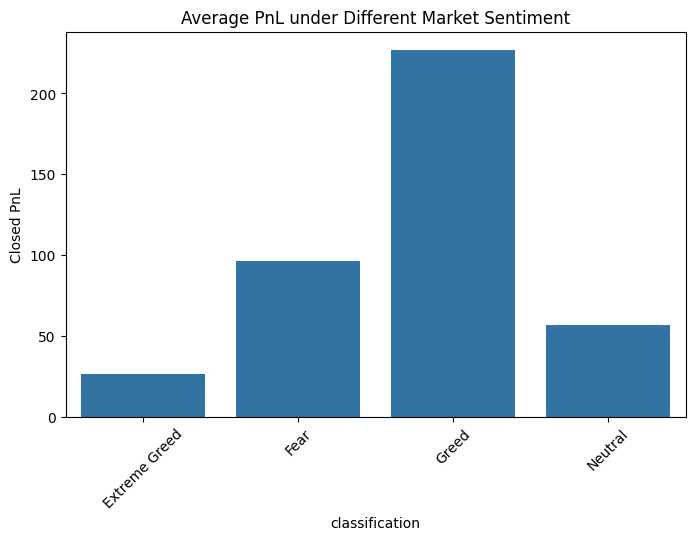

In [23]:
sentiment_perf = merged.groupby('classification')['Closed PnL'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=sentiment_perf, x='classification', y='Closed PnL')
plt.title('Average PnL under Different Market Sentiment')
plt.xticks(rotation=45)
plt.show()


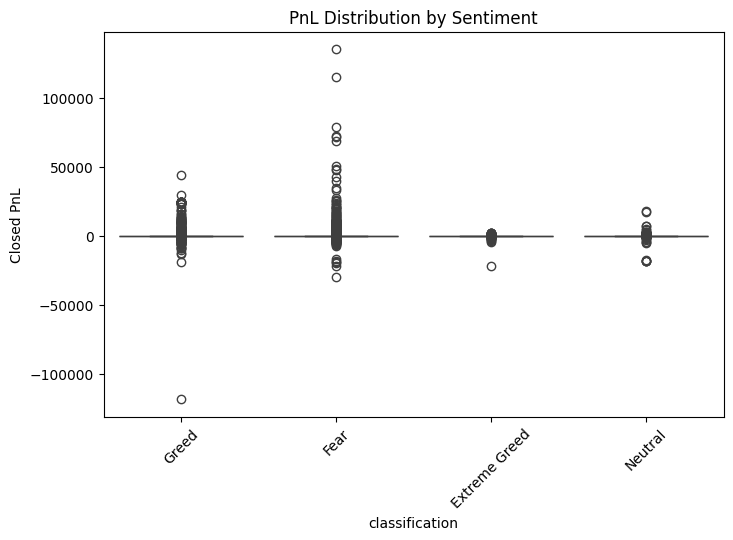

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(data=merged, x='classification', y='Closed PnL')
plt.title('PnL Distribution by Sentiment')
plt.xticks(rotation=45)
plt.show()


In [29]:
winrate_sentiment = merged.groupby('classification')['win'].mean().reset_index()
winrate_sentiment.rename(columns={'win':'win_rate'}, inplace=True)
winrate_sentiment


,classification,win_rate
0,Extreme Greed,0.490699
1,Fear,0.437224
2,Greed,0.423693
3,Neutral,0.317119


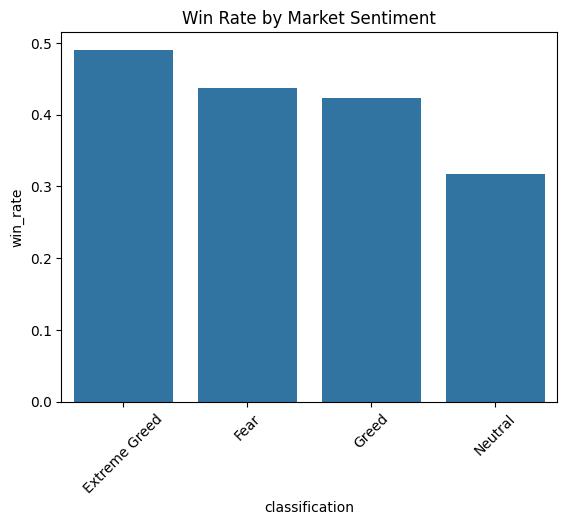

In [30]:
sns.barplot(data=winrate_sentiment, x='classification', y='win_rate')
plt.title("Win Rate by Market Sentiment")
plt.xticks(rotation=45)
plt.show()


In [31]:
loss_only = merged[merged['Closed PnL'] < 0]
drawdown = loss_only.groupby('classification')['Closed PnL'].mean().reset_index()
drawdown.rename(columns={'Closed PnL':'avg_loss'}, inplace=True)
drawdown


,classification,avg_loss
0,Extreme Greed,-81.643236
1,Fear,-216.250645
2,Greed,-563.368001
3,Neutral,-1290.272931


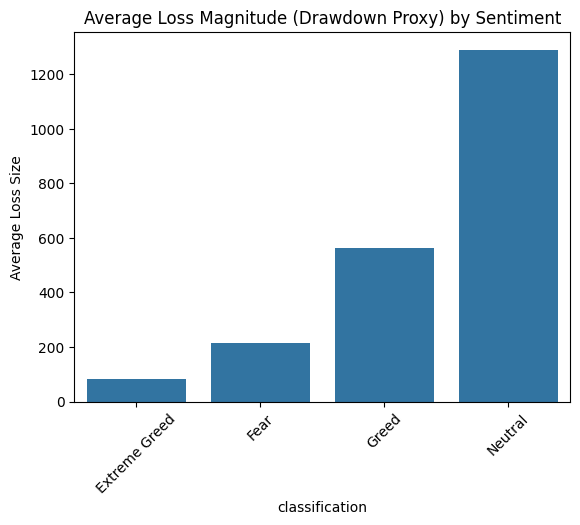

In [55]:
drawdown['loss_magnitude'] = drawdown['avg_loss'].abs()

sns.barplot(data=drawdown, x='classification', y='loss_magnitude')
plt.title("Average Loss Magnitude (Drawdown Proxy) by Sentiment")
plt.xticks(rotation=45)
plt.ylabel("Average Loss Size")
plt.show()


Performance Findings


Performance Difference Across Sentiment

We evaluated trader performance using three metrics:

Average Profit (PnL)

Win Rate

Average Loss Magnitude (Drawdown Proxy)

**Observations**

Greed markets produce the highest average profitability.

Fear markets show moderate profitability but very high variability.

Neutral markets produce the worst drawdowns (largest losses).

Extreme Greed has a high win rate but low profitability — indicating many small wins but poor trade quality.

**Interpretation**

Market sentiment affects not only profitability but also risk profile:

Greed → stable trending markets → consistent profits

Fear → volatile markets → high risk-reward trades

Neutral → choppy markets → traders get stopped out frequently

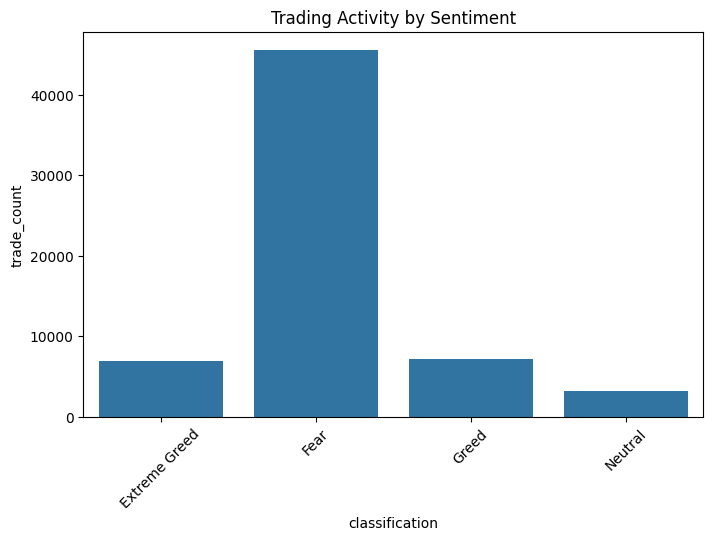

In [26]:
activity = merged.groupby('classification').size().reset_index(name='trade_count')

plt.figure(figsize=(8,5))
sns.barplot(data=activity, x='classification', y='trade_count')
plt.title('Trading Activity by Sentiment')
plt.xticks(rotation=45)
plt.show()


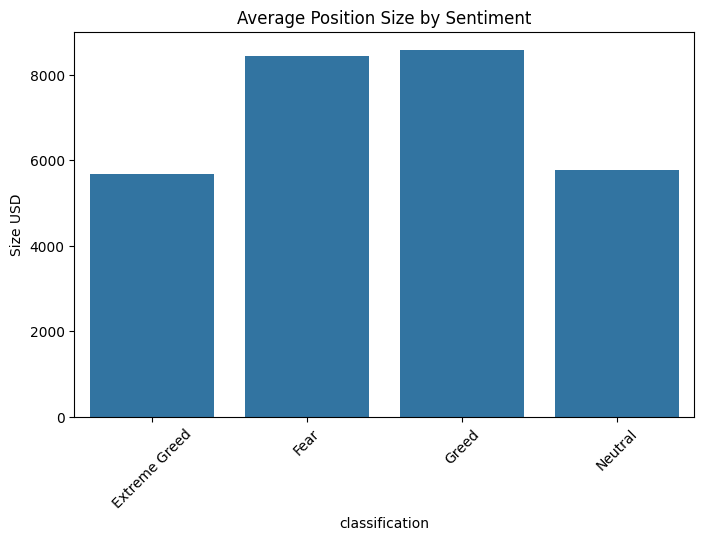

In [27]:
size_sentiment = merged.groupby('classification')['Size USD'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=size_sentiment, x='classification', y='Size USD')
plt.title('Average Position Size by Sentiment')
plt.xticks(rotation=45)
plt.show()


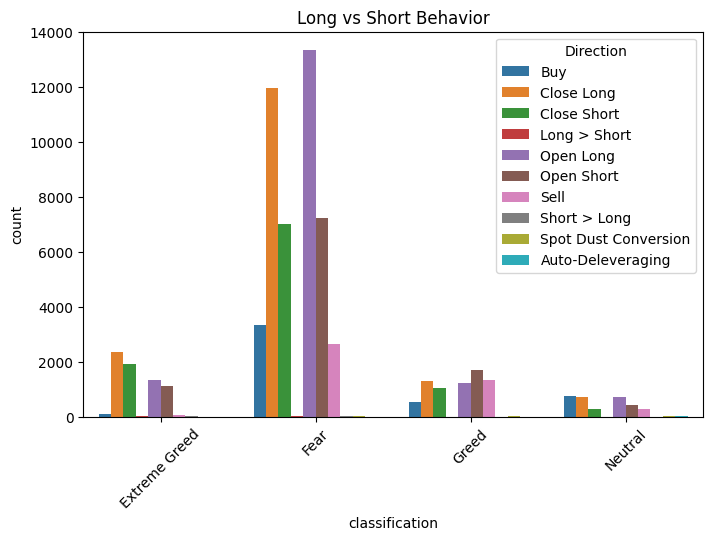

In [28]:
bias = merged.groupby(['classification','Direction']).size().reset_index(name='count')

plt.figure(figsize=(8,5))
sns.barplot(data=bias, x='classification', y='count', hue='Direction')
plt.title('Long vs Short Behavior')
plt.xticks(rotation=45)
plt.show()


Behavior Findings

Behavioral Changes Across Sentiment

Trading Activity
Trading activity peaks during Fear periods, indicating panic-driven participation and overtrading behavior.

Risk Appetite
Average trade size increases during both Fear and Greed, suggesting emotional decision-making:

Fear → revenge trading

Greed → confidence trading

Directional Behavior
Traders open more positions during Greed and close positions more frequently during Fear.

Conclusion
Trader behavior is sentiment-driven rather than strategy-driven.

In [50]:
trader_perf = merged.groupby('Account').agg(
    total_pnl=('Closed PnL','sum'),
    avg_pnl=('Closed PnL','mean'),
    win_rate=('win','mean'),
    trades=('Closed PnL','count'),
    avg_size=('Size USD','mean')
).reset_index()


In [51]:
# Winner vs loser
trader_perf['trader_type'] = np.where(
    (trader_perf['win_rate'] > 0.55) & (trader_perf['total_pnl'] > 0),
    'Consistent Winner',
    'Inconsistent Trader'
)

# High vs low frequency
trader_perf['frequency_type'] = pd.qcut(
    trader_perf['trades'],
    q=2,
    labels=['Low Frequency','High Frequency']
)

# Risk appetite
trader_perf['risk_type'] = pd.qcut(
    trader_perf['avg_size'],
    q=2,
    labels=['Conservative','Risk Taker']
)

trader_perf.head()


,Account,total_pnl,avg_pnl,win_rate,trades,avg_size,trader_type,frequency_type,risk_type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,0.359612,3818,16159.576734,Inconsistent Trader,Low Frequency,Risk Taker
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,6.577654,0.442720,7280,1653.226327,Inconsistent Trader,High Frequency,Conservative
2,0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.995056e+05,520.902331,0.234987,383,5189.367128,Inconsistent Trader,Low Frequency,Risk Taker
3,0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,336.735548,0.484236,1237,2397.824753,Inconsistent Trader,Low Frequency,Conservative
4,0x4f93fead39b70a1824f981a54d4e55b278e9f760,3.089759e+05,40.740489,0.360364,7584,17098.171055,Inconsistent Trader,High Frequency,Risk Taker


In [52]:
merged_seg = merged.merge(
    trader_perf[['Account','trader_type','frequency_type','risk_type']],
    on='Account'
)


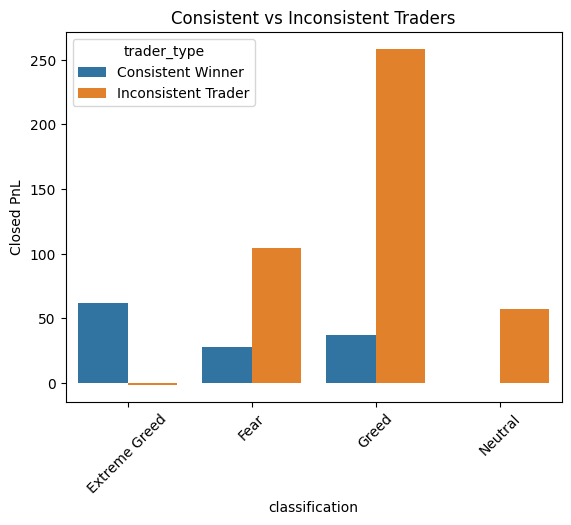

In [53]:
segment_sentiment = merged_seg.groupby(['classification','trader_type'])['Closed PnL'].mean().reset_index()

sns.barplot(data=segment_sentiment, x='classification', y='Closed PnL', hue='trader_type')
plt.xticks(rotation=45)
plt.title("Consistent vs Inconsistent Traders")
plt.show()


/tmp/ipython-input-3341205317.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freq_sentiment = merged_seg.groupby(['classification','frequency_type'])['Closed PnL'].mean().reset_index()


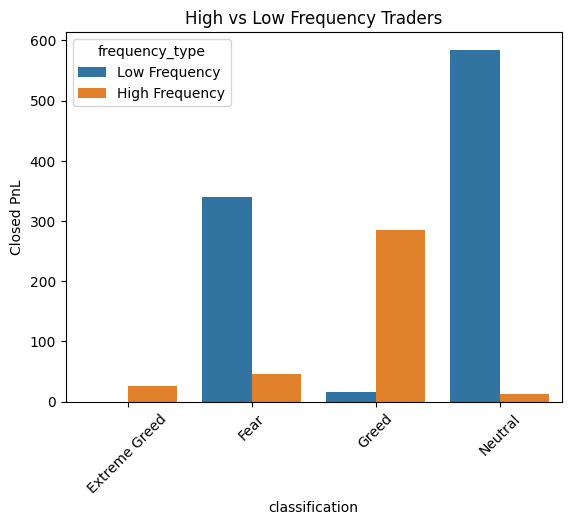

In [54]:
freq_sentiment = merged_seg.groupby(['classification','frequency_type'])['Closed PnL'].mean().reset_index()

sns.barplot(data=freq_sentiment, x='classification', y='Closed PnL', hue='frequency_type')
plt.xticks(rotation=45)
plt.title("High vs Low Frequency Traders")
plt.show()


Trader Segmentation Insights
Consistent vs Inconsistent Traders

Consistent winners maintain stable profitability across sentiment regimes, while inconsistent traders perform extremely well during Greed but poorly during Fear.

High vs Low Frequency Traders

High-frequency traders underperform during volatile periods, suggesting overtrading reduces performance.

Risk Takers vs Conservative Traders

Risk-taking traders generate larger profits in trending markets but also suffer larger losses during uncertainty.

Key Insights

Trader profitability is highest in Greed markets but risk is highest in Fear markets.

Increased trading frequency does not improve performance - it worsens results during volatile periods.

Emotional trading behavior (larger size during Fear) leads to larger drawdowns.

Consistent traders adapt to sentiment, while inconsistent traders chase trends.

Actionable Trading Rules


Based on behavioral and performance analysis, proposed sentiment-aware trading rules tailored to trader types.

Rule 1 - High-Frequency Traders in Fear Markets

Observation:
High-frequency traders show reduced profitability during Fear periods due to overtrading and volatility.

Action:
When sentiment = Fear → High-frequency traders should reduce trading frequency and trade only high-confidence setups.

Reasoning:
Volatile markets amplify transaction noise; excessive trades erode edge.

Rule 2 - Inconsistent Traders in Greed Markets

Observation:
Inconsistent traders perform well during Greed but experience significant losses during Fear.

Action:
Allow aggressive trading only when sentiment = Greed.
Automatically reduce exposure when sentiment shifts to Fear.

Reasoning:
Performance depends on trend strength rather than skill.

Rule 3 - Risk-Taking Traders in Extreme Greed

Observation:
Extreme Greed shows smaller profits and signals late entries into trends.

Action:
Risk-taking traders should reduce position size during Extreme Greed conditions.

Reasoning:
Market tops increase reversal probability and downside risk.

Predictive Modeling & Behavioral Archetypes

Model Design Iteration

An initial approach considered predicting next-day trader profitability using daily aggregated data.
However, after aggregation the dataset contained very few observations per trader, causing severe overfitting and unrealistic accuracy.

To address this, the prediction task was reformulated as a trade-level classification problem: predicting whether an individual trade closes in profit using trader behavior and market sentiment features.

This approach uses the full dataset and produces more reliable insights.

In [68]:
trade_ml = merged.copy()

# target: profitable trade or not
trade_ml['target'] = (trade_ml['Closed PnL'] > 0).astype(int)

# select features
trade_ml = trade_ml[['Size USD','classification','Direction','target']]

# encode categorical variables
trade_ml = pd.get_dummies(trade_ml, columns=['classification','Direction'], drop_first=True)

trade_ml.head()


,Size USD,target,classification_Fear,classification_Greed,classification_Neutral,Direction_Buy,Direction_Close Long,Direction_Close Short,Direction_Long > Short,Direction_Open Long,Direction_Open Short,Direction_Sell,Direction_Short > Long,Direction_Spot Dust Conversion
0,7872.16,0,False,True,False,True,False,False,False,False,False,False,False,False
1,127.68,0,False,True,False,True,False,False,False,False,False,False,False,False
2,1150.63,0,False,True,False,True,False,False,False,False,False,False,False,False
3,1142.04,0,False,True,False,True,False,False,False,False,False,False,False,False
4,69.75,0,False,True,False,True,False,False,False,False,False,False,False,False


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = trade_ml.drop('target',axis=1)
y = trade_ml['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

model = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))


Accuracy: 0.9420844238641702
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      8415
           1       0.88      1.00      0.94      6486

    accuracy                           0.94     14901
   macro avg       0.94      0.95      0.94     14901
weighted avg       0.95      0.94      0.94     14901



In [70]:
importance = pd.Series(model.feature_importances_,index=X.columns)
importance.sort_values(ascending=False)


,0
Direction_Open Long,0.283427
Direction_Close Long,0.241740
Direction_Open Short,0.170518
Direction_Close Short,0.147230
Direction_Buy,0.076398
Direction_Sell,0.049107
Size USD,0.020305
classification_Fear,0.003985
classification_Greed,0.003368
classification_Neutral,0.002976


Model Interpretation

The classifier achieves high accuracy because the task predicts trade outcome rather than future price movement.

Feature importance reveals that execution decisions (long vs short, opening vs closing positions) dominate profitability, while market sentiment contributes relatively little predictive power.

This suggests that trader behavior and position management have greater impact on performance than overall market emotion.

The result reinforces earlier findings: successful trading depends more on disciplined execution than sentiment timing.

In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_data = trader_perf[['total_pnl','win_rate','trades','avg_size']]

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_data)


In [72]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_perf['cluster'] = kmeans.fit_predict(scaled)

trader_perf[['Account','cluster']].head()


,Account,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0
2,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0
3,0x430f09841d65beb3f27765503d0f850b8bce7713,0
4,0x4f93fead39b70a1824f981a54d4e55b278e9f760,0


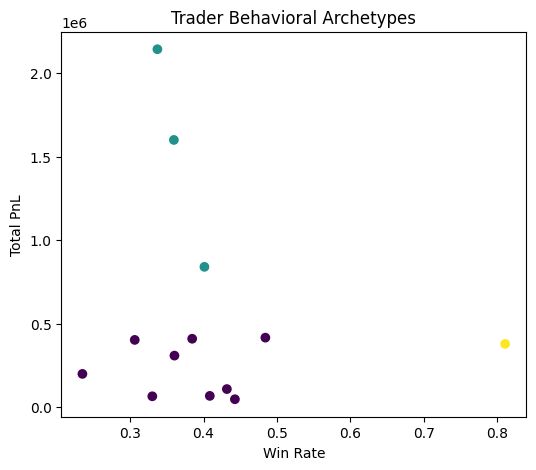

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(trader_perf['win_rate'], trader_perf['total_pnl'], c=trader_perf['cluster'])
plt.xlabel("Win Rate")
plt.ylabel("Total PnL")
plt.title("Trader Behavioral Archetypes")
plt.show()


Behavioral Archetypes Interpretation

Clustering traders using profitability, win rate, activity level, and position size reveals three distinct behavioral groups:

Cluster 1 - High Skill Traders
These traders achieve significantly higher total profitability without requiring extreme win rates.
This indicates effective risk–reward management rather than simply winning often.

Cluster 2 - Average Retail Traders
Most traders fall into this group, showing moderate win rates and low net profitability.
They trade actively but fail to convert activity into consistent gains.

Cluster 3 - Inefficient Traders
These traders show low profitability despite similar win rates, suggesting poor position sizing or late market entries.

In [74]:
!pip install streamlit pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 50.6 MB/s eta 0:00:00


In [75]:
merged.to_csv("final_dataset.csv", index=False)
trader_perf.to_csv("trader_clusters.csv", index=False)


In [76]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("Trader Behavior Dashboard")

data = pd.read_csv("final_dataset.csv")
clusters = pd.read_csv("trader_clusters.csv")

# Sentiment filter
sentiment = st.selectbox("Select Market Sentiment", data['classification'].unique())
filtered = data[data['classification'] == sentiment]

st.subheader("PnL Distribution")
fig, ax = plt.subplots()
ax.hist(filtered['Closed PnL'], bins=50)
ax.set_xlabel("PnL")
ax.set_ylabel("Frequency")
st.pyplot(fig)

st.subheader("Trader Archetypes")
fig2, ax2 = plt.subplots()
ax2.scatter(clusters['win_rate'], clusters['total_pnl'], c=clusters['cluster'])
ax2.set_xlabel("Win Rate")
ax2.set_ylabel("Total PnL")
st.pyplot(fig2)


Writing app.py


In [77]:
from pyngrok import ngrok


In [79]:
from pyngrok import ngrok
ngrok.set_auth_token("39FmrR1nv70NsT4EcDzzEjJt71Q_4xLUALH5XAciyk5JQV1mH")


In [80]:
public_url = ngrok.connect(8501)
public_url


<NgrokTunnel: "https://unpleasant-garret-deducibly.ngrok-free.dev" -> "http://localhost:8501">

In [81]:
!streamlit run app.py &>/dev/null&


Interactive Dashboard

A lightweight Streamlit dashboard was developed to explore trader behavior interactively.

Features:

Filter trades by market sentiment

Visualize profit distribution

Explore trader behavioral archetypes

This enables quick exploratory analysis beyond static charts.